In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

## RED DAÑADA

In [ ]:
# --- CARGAR datos ---
Omega_damage_array = np.load('../Omega_damage_list.npy')
Omega_damage_list = [Omega_damage_array[i] for i in range(Omega_damage_array.shape[0])]
A = np.load('../A_origin.npy')
G = nx.from_numpy_array(A, create_using=nx.DiGraph)


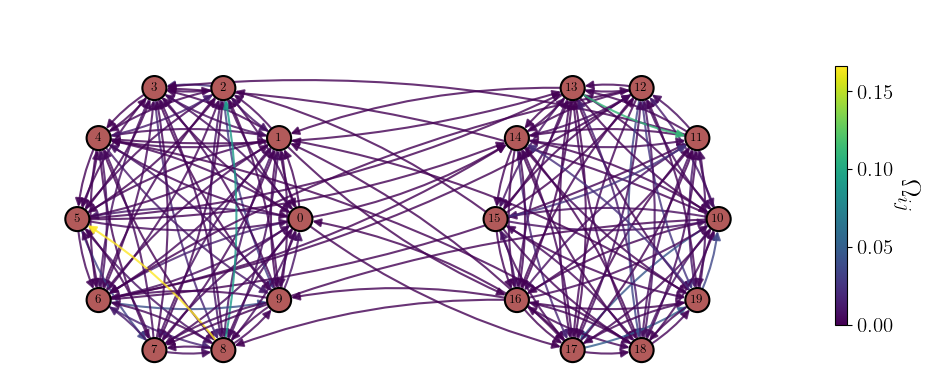

In [45]:


# Seleccionamos una matriz de peso dañada (por ejemplo, la primera simulación)
# Omega_damage_list[0]
weights_matrix = Omega_damage_list[2]

# 2. Definir posiciones (Mantenemos tu estructura de dos comunidades)
N_com = 10 
pos = {}
for i in range(N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i in range(N_com, 2 * N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

# 3. Configuración de la gráfica
fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
node_colors = ['#B25A5A'] * N_com + ['#B25A5A'] * N_com

# Extraer aristas y sus pesos correspondientes de la matriz Omega
edges = list(G.edges())
weights = [weights_matrix[u, v] for u, v in edges]

# 4. Dibujar Nodos
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color=node_colors, 
                       edgecolors='black', linewidths=1.5)

# 5. Dibujar Aristas con Flechas y Curvatura
# La curvatura (connectionstyle) es vital para ver flechas i->j y j->i por separado
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                       width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.viridis,
                       arrowstyle='-|>', 
                       arrowsize=12, 
                       connectionstyle='arc3,rad=0.1', 
                       alpha=0.8)

# 6. Etiquetas y Barra de Color
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color='black', font_weight='bold')

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=np.min(weights), vmax=np.max(weights)))
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label(r'$\Omega_{ij}$', rotation=270, labelpad=20, fontsize=20)
cbar.ax.tick_params(labelsize=15)

ax.axis('off')
plt.tight_layout()

savefig_name='Dos_comunidades.pdf'
plt.savefig(savefig_name,bbox_inches="tight")
plt.show()

## FUNCIONALIDAD ESTOCASTICA

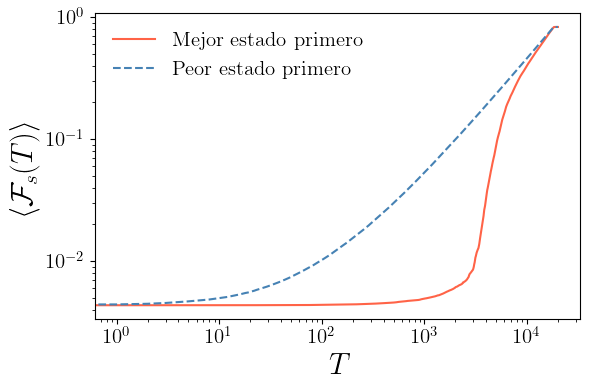

In [ ]:
avg_repair = np.load('F_Deterministic_Strategy.npy', allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
t_repair = np.arange(T_repair + 1)

strategies = ['best', 'worst']

strategy_config = {
    'best':  ('Mejor estado primero', 'tomato', '-', 1.5),
    'worst': ('Peor estado primero',  'steelblue', '--', 1.5),
}

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

for s in strategies:
    label, color, style, lw = strategy_config[s]

    plt.loglog(
        t_repair,
        avg_repair[s],
        linestyle=style,
        color=color,
        linewidth=lw,
        label=label
    )


plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(
    loc='upper left',
    frameon=False,
    fontsize=15
)
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Deterministica.pdf', bbox_inches="tight")

plt.show()

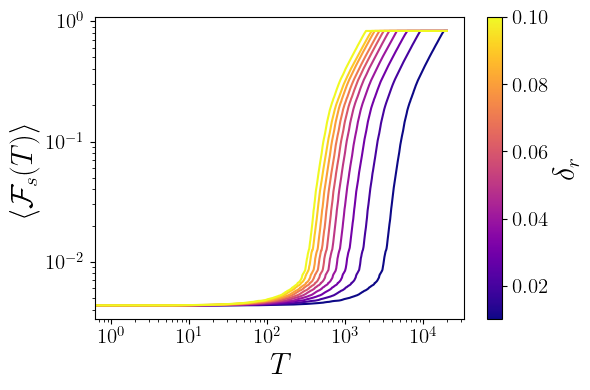

In [ ]:
avg_repair = np.load('F_Deterministic_deltar_Best.npy', allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5,
        label=rf"$\delta_r = {d:.2f}$"
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Deterministica_delta_r_best.pdf',
            bbox_inches="tight")

plt.show()

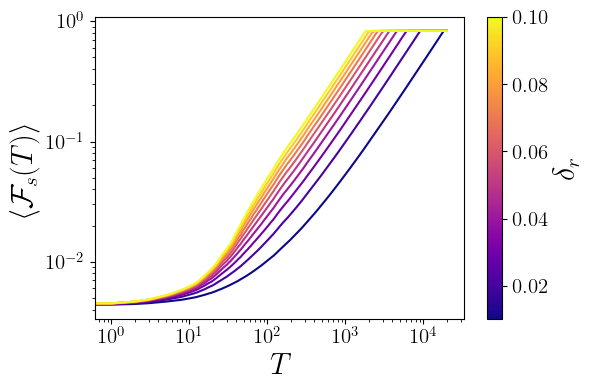

In [ ]:
avg_repair = np.load('F_Deterministic_deltar_worst.npy', allow_pickle=True).item()

# --- PARÁMETROS ---
T_repair = 25000
deltas_r = np.linspace(0.01, 0.1, 10)

t_repair = np.arange(T_repair + 1)

# --- COLORMAP ---
colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

# --- FIGURA ---
plt.figure(figsize=(6, 4), facecolor="white")

# --- CURVAS ---
for d in deltas_r:
    color = colormap(norm(d))

    plt.loglog(
        t_repair,
        avg_repair[d],
        color=color,
        linewidth=1.5,
        label=rf"$\delta_r = {d:.2f}$"
    )

# --- COLORBAR ---
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=plt.gca())

cbar.set_label(r'$\delta_r$', fontsize=22)
cbar.ax.tick_params(labelsize=15)

plt.xlabel(r"$T$", fontsize=22)
plt.ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()

# --- GUARDAR ---
plt.savefig('Funcionalidad_Deterministica_delta_r_worst.pdf',
            bbox_inches="tight")

plt.show()